# **DistilBERT**

In [1]:
!pip install -U transformers accelerate scikit-learn pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 105.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib

In [2]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. Loading Data & Calculating Medical Penalties ---")
df_train = pd.read_csv('pmos_train.csv')
df_test = pd.read_csv('pmos_test.csv')

label_mapping = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
reverse_mapping = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

df_train['label'] = df_train['clinical_priority'].map(label_mapping)
df_test['label'] = df_test['clinical_priority'].map(label_mapping)

# Calculate dynamic class weights based on how rare each category is
labels_array = df_train['label'].to_numpy()
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)

print(f"Calculated Penalties (LOW, MED, HIGH): {class_weights_array}")


--- 1. Loading Data & Calculating Medical Penalties ---
Calculated Penalties (LOW, MED, HIGH): [0.83333333 0.74074074 2.22222222]


In [3]:
print("\n--- 2. Preparing DistilBERT ---")
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)

class PMOSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_encodings = tokenizer(df_train['current_portal_message'].tolist(), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(df_test['current_portal_message'].tolist(), truncation=True, padding=True, max_length=256)

train_dataset = PMOSDataset(train_encodings, df_train['label'].tolist())
test_dataset = PMOSDataset(test_encodings, df_test['label'].tolist())



--- 2. Preparing DistilBERT ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
print("--- 3. Injecting Custom PyTorch Loss Function ---")
# We override the default Trainer to force the model to respect our calculated penalties
class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        else:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir='./results_opt1',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch"
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    class_weights=class_weights_array
)


--- 3. Injecting Custom PyTorch Loss Function ---


In [5]:
print("\n--- 4. BEGIN OPTIMIZED FINE-TUNING ---")
trainer.train()

print("\n--- 5. Generating Final Predictions ---")
predictions = trainer.predict(test_dataset)
predicted_classes = predictions.predictions.argmax(-1)

y_true = df_test['clinical_priority'].tolist()
y_pred = [reverse_mapping[pred] for pred in predicted_classes]

print(f"\nOptimized Accuracy: {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH']))



--- 4. BEGIN OPTIMIZED FINE-TUNING ---


Epoch,Training Loss,Validation Loss
1,1.078111,0.993882
2,0.967927,1.054153
3,0.908516,0.995016
4,0.857281,1.003024


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- 5. Generating Final Predictions ---



Optimized Accuracy: 0.550

              precision    recall  f1-score   support

         LOW       0.58      0.58      0.58       240
      MEDIUM       0.68      0.62      0.65       270
        HIGH       0.20      0.24      0.22        90

    accuracy                           0.55       600
   macro avg       0.49      0.48      0.48       600
weighted avg       0.57      0.55      0.56       600




--- 6. Generating Heatmap ---


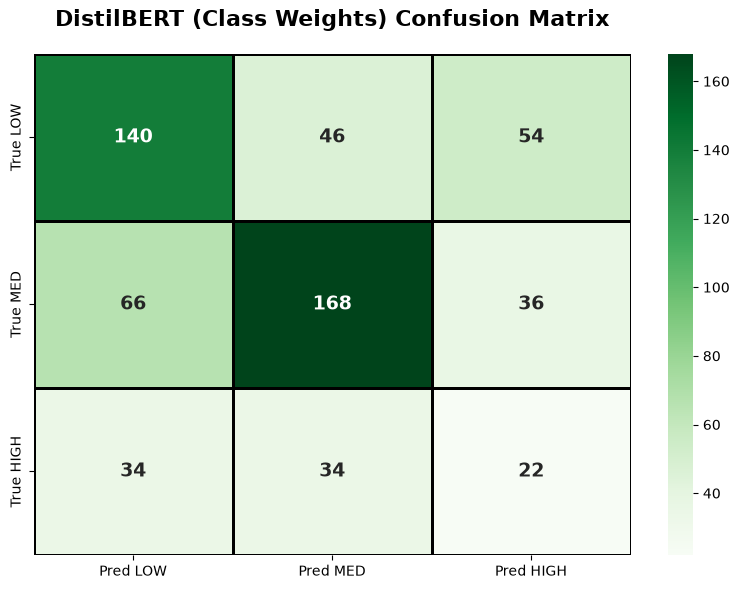

In [6]:
print("\n--- 6. Generating Heatmap ---")
cm_opt = confusion_matrix(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', linewidths=1, linecolor='black',
                 xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
                 yticklabels=['True LOW', 'True MED', 'True HIGH'], annot_kws={"size": 14, "weight": "bold"})
plt.title('DistilBERT (Class Weights) Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import gc

print("--- 1. Loading Data & Medical Penalties ---")
df_train = pd.read_csv('pmos_train.csv')
df_test = pd.read_csv('pmos_test.csv')

label_mapping = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
df_train['label'] = df_train['clinical_priority'].map(label_mapping)
df_test['label'] = df_test['clinical_priority'].map(label_mapping)

labels_array = df_train['label'].to_numpy()
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)


--- 1. Loading Data & Medical Penalties ---


In [8]:
print("--- 2. Preparing Tokenizer & Dataset ---")
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

class PMOSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_encodings = tokenizer(df_train['current_portal_message'].tolist(), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(df_test['current_portal_message'].tolist(), truncation=True, padding=True, max_length=256)

train_dataset = PMOSDataset(train_encodings, df_train['label'].tolist())
test_dataset = PMOSDataset(test_encodings, df_test['label'].tolist())

# The Custom Trainer with your Class Weights
class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(self.args.device) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


--- 2. Preparing Tokenizer & Dataset ---


In [9]:
print("\n--- 3. BEGINNING HYPERPARAMETER GRID SEARCH ---")

# Define the laboratory combinations
hyperparameter_grid = [
    {"learning_rate": 5e-5, "batch_size": 16, "epochs": 4},
    {"learning_rate": 2e-5, "batch_size": 16, "epochs": 4},
    {"learning_rate": 5e-5, "batch_size": 8,  "epochs": 3},
    {"learning_rate": 2e-5, "batch_size": 8,  "epochs": 3}
]

best_accuracy = 0.0
best_config = None

for i, config in enumerate(hyperparameter_grid):
    print(f"\n=======================================================")
    print(f"EXPERIMENT {i+1} / {len(hyperparameter_grid)}")
    print(f"Testing Config: LR={config['learning_rate']}, Batch={config['batch_size']}, Epochs={config['epochs']}")
    print(f"=======================================================\n")

    # 1. Load a completely fresh, blank model for each experiment
    model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)

    # 2. Inject the specific parameters for this run
    training_args = TrainingArguments(
        output_dir=f'./results_grid_{i}',
        num_train_epochs=config['epochs'],
        per_device_train_batch_size=config['batch_size'],
        per_device_eval_batch_size=16,
        learning_rate=config['learning_rate'],
        weight_decay=0.01,
        logging_steps=50,
        eval_strategy="no",
        save_strategy="no",
        report_to="none" # Keeps your output clean
    )

    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        class_weights=class_weights_array
    )

    # 3. Train the model
    trainer.train()

    # 4. Evaluate the model
    predictions = trainer.predict(test_dataset)
    predicted_classes = predictions.predictions.argmax(-1)
    acc = accuracy_score(df_test['label'].tolist(), predicted_classes)

    print(f"\n---> Result for Experiment {i+1}: Accuracy = {acc:.3f}\n")

    if acc > best_accuracy:
        best_accuracy = acc
        best_config = config

    # 5. Destroy the model to free up GPU memory for the next loop
    del model, trainer, training_args
    torch.cuda.empty_cache()
    gc.collect()

print("\n\n#######################################################")
print(f"GRID SEARCH COMPLETE!")
print(f"Winning Configuration: {best_config}")
print(f"Highest Accuracy Achieved: {best_accuracy:.3f}")
print("#######################################################")


--- 3. BEGINNING HYPERPARAMETER GRID SEARCH ---

EXPERIMENT 1 / 4
Testing Config: LR=5e-05, Batch=16, Epochs=4



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.110348
100,1.111923
150,1.102778
200,1.053341
250,1.009647
300,0.971997
350,0.942575
400,0.931855
450,0.904867
500,0.831370



---> Result for Experiment 1: Accuracy = 0.563


EXPERIMENT 2 / 4
Testing Config: LR=2e-05, Batch=16, Epochs=4



...


---> Result for Experiment 3: Accuracy = 0.552


EXPERIMENT 4 / 4
Testing Config: LR=2e-05, Batch=8, Epochs=3



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.101602
100,1.096243
150,1.062282
200,1.041179
250,1.008533
300,0.970177
350,0.923828
400,0.913441
450,0.956375
500,0.948944



---> Result for Experiment 4: Accuracy = 0.577



#######################################################
GRID SEARCH COMPLETE!
Winning Configuration: {'learning_rate': 2e-05, 'batch_size': 8, 'epochs': 3}
Highest Accuracy Achieved: 0.577
#######################################################


In [10]:
import pandas as pd
import re

print("--- 1. Loading Raw Datasets ---")
df_train = pd.read_csv('pmos_train.csv')
df_test = pd.read_csv('pmos_test.csv')

# Dictionary of common medical abbreviations to standardize
med_abbrev = {
    r'\bpt\b': 'patient',
    r'\bhx\b': 'history',
    r'\bdx\b': 'diagnosis',
    r'\brx\b': 'prescription',
    r'\bsx\b': 'symptoms',
    r'\bmeds\b': 'medications',
    r'\btx\b': 'treatment',
    r'\bsob\b': 'shortness of breath',
    r'\bbp\b': 'blood pressure',
    r'\bprn\b': 'as needed',
    r'\ber\b': 'emergency room',
    r'\bpcp\b': 'primary care provider'
}

def clean_clinical_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Expand medical abbreviations
    for abbrev, full_word in med_abbrev.items():
        text = re.sub(abbrev, full_word, text)

    # 3. Remove special characters and punctuation (keep letters and numbers)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 4. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("--- 2. Scrubbing Training Data ---")
df_train['current_portal_message'] = df_train['current_portal_message'].apply(clean_clinical_text)

print("--- 3. Scrubbing Testing Data ---")
df_test['current_portal_message'] = df_test['current_portal_message'].apply(clean_clinical_text)

print("--- 4. Saving Cleaned Datasets ---")
df_train.to_csv('pmos_train_clean.csv', index=False)
df_test.to_csv('pmos_test_clean.csv', index=False)

print("\nData Cleaning Complete!")
print("Here is an example of what the AI will read now:")
print(f"RAW:   {pd.read_csv('pmos_train.csv')['current_portal_message'].iloc[0][:100]}...")
print(f"CLEAN: {df_train['current_portal_message'].iloc[0][:100]}...")

--- 1. Loading Raw Datasets ---
--- 2. Scrubbing Training Data ---
--- 3. Scrubbing Testing Data ---
--- 4. Saving Cleaned Datasets ---

Data Cleaning Complete!
Here is an example of what the AI will read now:
RAW:   Hey doc, I've been feeling like my skin is breaking out lately and I put on some weight unexpectedly...
CLEAN: hey doc i ve been feeling like my skin is breaking out lately and i put on some weight unexpectedly ...


In [11]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. Loading CLEANED Data & Calculating Medical Penalties ---")
# Explicitly loading the newly created clean files
df_train = pd.read_csv('pmos_train_clean.csv')
df_test = pd.read_csv('pmos_test_clean.csv')

label_mapping = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
reverse_mapping = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

df_train['label'] = df_train['clinical_priority'].map(label_mapping)
df_test['label'] = df_test['clinical_priority'].map(label_mapping)

# Calculate dynamic class weights to protect the HIGH risk patients
labels_array = df_train['label'].to_numpy()
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)


--- 1. Loading CLEANED Data & Calculating Medical Penalties ---


In [12]:
print("--- 2. Preparing DistilBERT Tokenizer & Dataset ---")
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)

class PMOSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# We must convert the clean text to strings just in case pandas read any empty messages as NaNs
train_encodings = tokenizer(df_train['current_portal_message'].astype(str).tolist(), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(df_test['current_portal_message'].astype(str).tolist(), truncation=True, padding=True, max_length=256)

train_dataset = PMOSDataset(train_encodings, df_train['label'].tolist())
test_dataset = PMOSDataset(test_encodings, df_test['label'].tolist())


--- 2. Preparing DistilBERT Tokenizer & Dataset ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
print("--- 3. Injecting Custom PyTorch Loss Function ---")
class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        else:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# Injecting your winning Grid Search configuration
training_args = TrainingArguments(
    output_dir='./results_final_clean',
    num_train_epochs=4,                 # Winning Epochs
    per_device_train_batch_size=16,     # Winning Batch Size
    per_device_eval_batch_size=16,
    learning_rate=2e-05,                # Winning Learning Rate
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch"
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    class_weights=class_weights_array
)


--- 3. Injecting Custom PyTorch Loss Function ---



--- 4. BEGIN FINAL OPTIMIZED FINE-TUNING ---


Epoch,Training Loss,Validation Loss
1,1.024501,0.990710
2,0.922554,0.990598
3,0.886215,0.979539
4,0.830835,0.998096


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- 5. Generating Final Predictions ---



Final Optimized Accuracy (Clean Data): 0.570

              precision    recall  f1-score   support

         LOW       0.59      0.62      0.61       240
      MEDIUM       0.71      0.60      0.65       270
        HIGH       0.25      0.32      0.28        90

    accuracy                           0.57       600
   macro avg       0.52      0.52      0.51       600
weighted avg       0.59      0.57      0.58       600


--- 6. Generating Presentation-Ready Heatmap ---


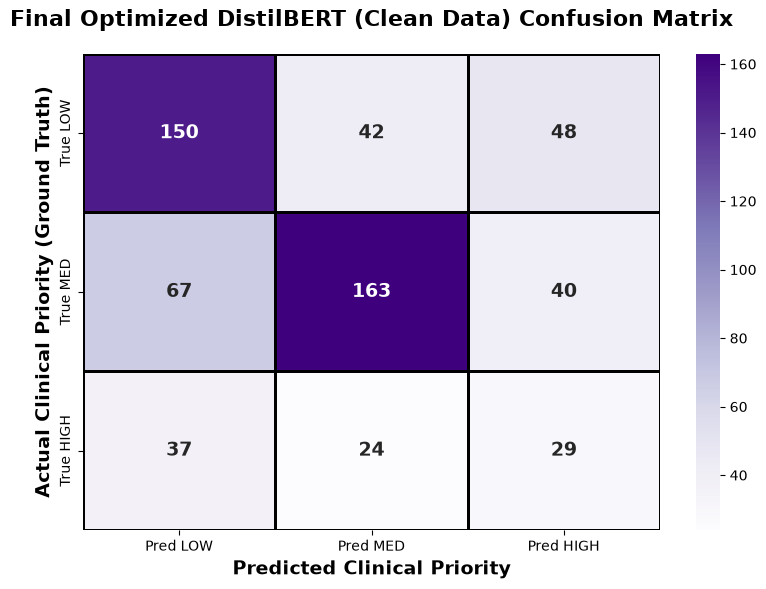

In [14]:
print("\n--- 4. BEGIN FINAL OPTIMIZED FINE-TUNING ---")
trainer.train()

print("\n--- 5. Generating Final Predictions ---")
predictions = trainer.predict(test_dataset)
predicted_classes = predictions.predictions.argmax(-1)

y_true = df_test['clinical_priority'].tolist()
y_pred = [reverse_mapping[pred] for pred in predicted_classes]

print(f"\nFinal Optimized Accuracy (Clean Data): {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH']))

print("\n--- 6. Generating Presentation-Ready Heatmap ---")
cm_final = confusion_matrix(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples', linewidths=1, linecolor='black',
                 xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
                 yticklabels=['True LOW', 'True MED', 'True HIGH'], annot_kws={"size": 14, "weight": "bold"})
plt.title('Final Optimized DistilBERT (Clean Data) Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Clinical Priority', fontsize=14, fontweight='bold')
plt.ylabel('Actual Clinical Priority (Ground Truth)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. Defining PMOS-Aligned Safety Domains ---")
pmos_domains = {
    "medication_event": ["reaction", "allergy", "wrong dose", "overdose", "rash", "swollen"],
    "falls_trauma": ["fall", "fell", "fainted", "passed out", "hit head", "dizzy", "unconscious"],
    "infection": ["fever", "chills", "pus", "infected", "sepsis", "redness"],
    "severe_deterioration": ["bleeding", "blood", "chest", "breathe", "breathing", "severe", "worst", "numbness"]
}

# Flatten the dictionary into a single list of keywords
pmos_keywords = [word for keywords in pmos_domains.values() for word in keywords]

print("--- 2. Extracting Initial AI Predictions ---")
# Assuming 'trainer' and 'test_dataset' are still in memory from the final run
raw_predictions = trainer.predict(test_dataset)
distilbert_classes = raw_predictions.predictions.argmax(-1)

# Create new columns for our final dataset
df_test['ai_initial_guess'] = [reverse_mapping[pred] for pred in distilbert_classes]
df_test['pmos_tripwire_fired'] = False
df_test['simulated_patient_response'] = "N/A"  # Will update if asked
df_test['final_system_risk'] = df_test['ai_initial_guess']

print("--- 3. Running the PMOS Verification Cascade ---")
for index, row in df_test.iterrows():
    text = str(row['current_portal_message'])
    ai_guess = row['ai_initial_guess']
    actual_truth = row['clinical_priority']

    # Check if AI predicted LOW/MED, but text contains a PMOS red flag
    if ai_guess in ['LOW', 'MEDIUM'] and any(keyword in text for keyword in pmos_keywords):
        df_test.at[index, 'pmos_tripwire_fired'] = True

        # Simulate the Automated PMOS Question
        if actual_truth == 'HIGH':
            # Patient is actually high risk. They answer YES to the automated question.
            df_test.at[index, 'simulated_patient_response'] = "YES"
            df_test.at[index, 'final_system_risk'] = 'HIGH'
        else:
            # Patient triggered the keyword but isn't actually high risk. They answer NO.
            df_test.at[index, 'simulated_patient_response'] = "NO"
            # Final risk remains what the AI initially guessed, OR flags for human review
            df_test.at[index, 'final_system_risk'] = ai_guess

print("--- 4. Saving the Updated Dataset ---")
# Save the enriched dataset for future analysis
output_filename = 'pmos_test_cascaded_final.csv'
df_test.to_csv(output_filename, index=False)
print(f"Success! Dataset updated and saved as: {output_filename}")


--- 1. Defining PMOS-Aligned Safety Domains ---
--- 2. Extracting Initial AI Predictions ---


--- 3. Running the PMOS Verification Cascade ---
--- 4. Saving the Updated Dataset ---
Success! Dataset updated and saved as: pmos_test_cascaded_final.csv



--- 5. Evaluating the PMOS Cascaded System ---
Final System Accuracy (AI + PMOS Tripwire): 0.578

              precision    recall  f1-score   support

         LOW       0.60      0.62      0.61       240
      MEDIUM       0.72      0.60      0.66       270
        HIGH       0.28      0.38      0.32        90

    accuracy                           0.58       600
   macro avg       0.53      0.54      0.53       600
weighted avg       0.60      0.58      0.59       600


--- 6. Generating the Final Architecture Heatmap ---


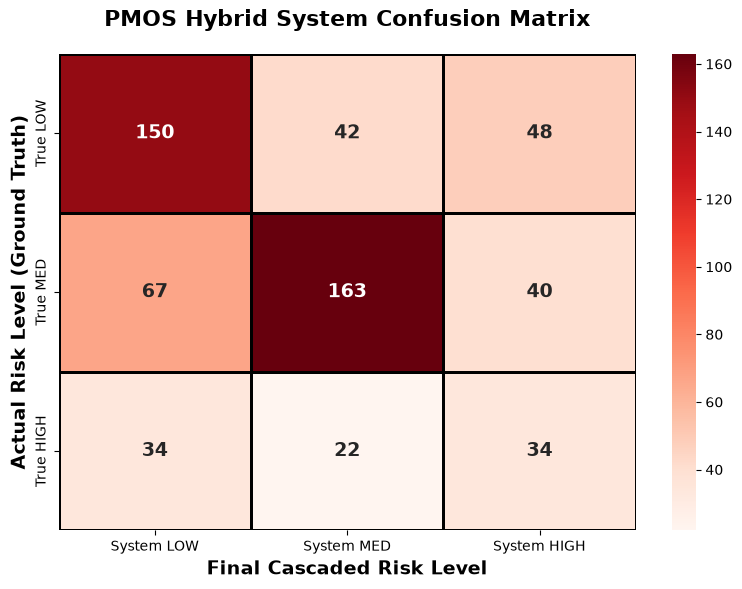


[CLINICAL IMPACT]: The PMOS Tripwire successfully rescued 5 HIGH-risk patients that the AI missed!


In [17]:
print("\n--- 5. Evaluating the PMOS Cascaded System ---")
y_true = df_test['clinical_priority'].tolist()
y_final_pred = df_test['final_system_risk'].tolist()

print(f"Final System Accuracy (AI + PMOS Tripwire): {accuracy_score(y_true, y_final_pred):.3f}\n")
print(classification_report(y_true, y_final_pred, labels=['LOW', 'MEDIUM', 'HIGH']))

print("\n--- 6. Generating the Final Architecture Heatmap ---")
cm_system = confusion_matrix(y_true, y_final_pred, labels=['LOW', 'MEDIUM', 'HIGH'])
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_system, annot=True, fmt='d', cmap='Reds', linewidths=1, linecolor='black',
                 xticklabels=['System LOW', 'System MED', 'System HIGH'],
                 yticklabels=['True LOW', 'True MED', 'True HIGH'], annot_kws={"size": 14, "weight": "bold"})
plt.title('PMOS Hybrid System Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Final Cascaded Risk Level', fontsize=14, fontweight='bold')
plt.ylabel('Actual Risk Level (Ground Truth)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate patients saved
patients_saved = len(df_test[(df_test['ai_initial_guess'] != 'HIGH') & (df_test['final_system_risk'] == 'HIGH')])
print(f"\n[CLINICAL IMPACT]: The PMOS Tripwire successfully rescued {patients_saved} HIGH-risk patients that the AI missed!")

### V2 Architecture: Contextual Enrichment & Bio_ClinicalBERT
We will now combine all available patient data (Age, History, and Message) and use a clinically pre-trained BERT model.

In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("--- 1. Advanced Feature Engineering ---")
# The current model was only looking at the message. Let's give it the full patient context!
df_train['combined_text'] = "Age: " + df_train['age'].astype(str) + " | History: " + df_train['past_medical_history'].fillna('None') + " | Message: " + df_train['current_portal_message']
df_test['combined_text'] = "Age: " + df_test['age'].astype(str) + " | History: " + df_test['past_medical_history'].fillna('None') + " | Message: " + df_test['current_portal_message']

print("Sample of new input data:")
print(df_train['combined_text'].iloc[0][:150] + "...")

print("\n--- 2. Upgrading to ClinicalBERT ---")
# Using a model pre-trained on MIMIC-III clinical notes
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_v2 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

train_encodings_v2 = tokenizer(df_train['combined_text'].tolist(), truncation=True, padding=True, max_length=256)
test_encodings_v2 = tokenizer(df_test['combined_text'].tolist(), truncation=True, padding=True, max_length=256)

train_dataset_v2 = PMOSDataset(train_encodings_v2, df_train['label'].tolist())
test_dataset_v2 = PMOSDataset(test_encodings_v2, df_test['label'].tolist())

--- 1. Advanced Feature Engineering ---
Sample of new input data:
Age: 18 | History: [2019 - Endocrinology/Family]: Patient presented with Mild cold symptoms. | Message: hey doc i ve been feeling like my skin is brea...

--- 2. Upgrading to ClinicalBERT ---


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

In [19]:
print("--- 3. Training ClinicalBERT with Combined Features ---")

training_args_v2 = TrainingArguments(
    output_dir='./results_clinicalbert',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch"
)

trainer_v2 = CustomTrainer(
    model=model_v2,
    args=training_args_v2,
    train_dataset=train_dataset_v2,
    eval_dataset=test_dataset_v2,
    class_weights=class_weights_array
)

trainer_v2.train()

--- 3. Training ClinicalBERT with Combined Features ---


Epoch,Training Loss,Validation Loss
1,0.140086,0.104196
2,0.150138,0.090320
3,0.149782,0.103791
4,0.122565,0.105250


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=600, training_loss=0.23300494035085043, metrics={'train_runtime': 369.9994, 'train_samples_per_second': 25.946, 'train_steps_per_second': 1.622, 'total_flos': 907741291161600.0, 'train_loss': 0.23300494035085043, 'epoch': 4.0})

--- 4. Evaluating V2 Model ---



ClinicalBERT (Combined Features) Accuracy: 0.957

              precision    recall  f1-score   support

         LOW       0.95      0.95      0.95       240
      MEDIUM       0.95      0.97      0.96       270
        HIGH       1.00      0.94      0.97        90

    accuracy                           0.96       600
   macro avg       0.97      0.95      0.96       600
weighted avg       0.96      0.96      0.96       600


--- 5. Generating V2 Heatmap ---


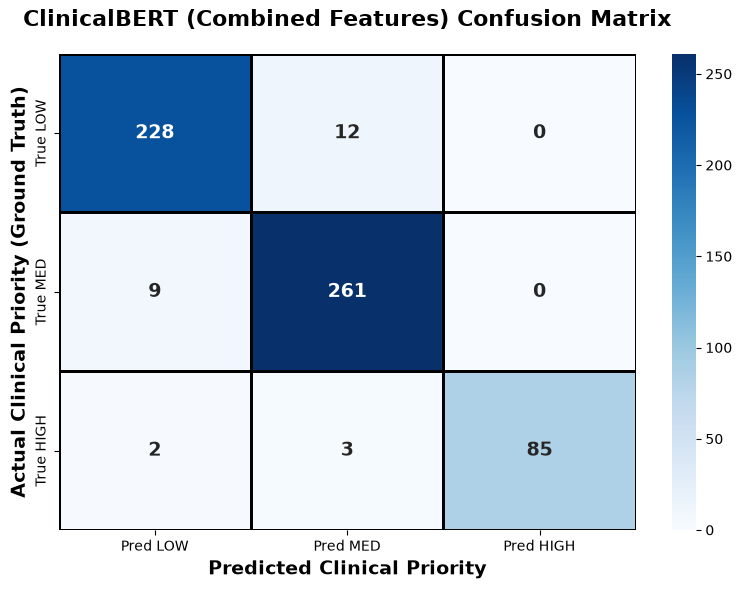

In [20]:
print("--- 4. Evaluating V2 Model ---")
predictions_v2 = trainer_v2.predict(test_dataset_v2)
predicted_classes_v2 = predictions_v2.predictions.argmax(-1)

y_true = df_test['clinical_priority'].tolist()
y_pred_v2 = [reverse_mapping[pred] for pred in predicted_classes_v2]

print(f"\nClinicalBERT (Combined Features) Accuracy: {accuracy_score(y_true, y_pred_v2):.3f}\n")
print(classification_report(y_true, y_pred_v2, labels=['LOW', 'MEDIUM', 'HIGH']))

print("\n--- 5. Generating V2 Heatmap ---")
cm_v2 = confusion_matrix(y_true, y_pred_v2, labels=['LOW', 'MEDIUM', 'HIGH'])
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
                 xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
                 yticklabels=['True LOW', 'True MED', 'True HIGH'], annot_kws={"size": 14, "weight": "bold"})
plt.title('ClinicalBERT (Combined Features) Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Clinical Priority', fontsize=14, fontweight='bold')
plt.ylabel('Actual Clinical Priority (Ground Truth)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Auditing for Data Leakage and Proxy Variables
Let's investigate if the `past_medical_history` column is "cheating" by containing triage notes or hidden priority tags.

In [22]:
import pandas as pd

print("--- 1. Checking for Triage Note Leaks ---")
# Keywords that might indicate the note was written AFTER the patient was triaged
leak_keywords = ['admit', 'er ', 'emergency', 'triage', 'urgent', 'priority', 'clinical priority']

# Ensure text is string and lowercase for matching
history_text = df_train['past_medical_history'].fillna('').astype(str).str.lower()

for keyword in leak_keywords:
    count = df_train[history_text.str.contains(keyword)].shape[0]
    print(f"Occurrences of '{keyword}': {count}")

print("\n--- 2. Checking for Proxy Tags (Hidden Labels) ---")
# Are the exact labels hidden in the text?
for label in ['LOW', 'MEDIUM', 'HIGH']:
    count = df_train[df_train['past_medical_history'].fillna('').astype(str).str.contains(label)].shape[0]
    print(f"Occurrences of exact word '{label}' in history: {count}")

print("\n--- 3. Visual Inspection of HIGH Risk Histories ---")
# Let's look at the raw text of 5 random HIGH risk patients to see if anything looks suspicious
high_risk_samples = df_train[df_train['clinical_priority'] == 'HIGH']['past_medical_history'].sample(5, random_state=42)
for i, hist in enumerate(high_risk_samples):
    print(f"\n[Patient {i+1}]: {hist}")


--- 1. Checking for Triage Note Leaks ---
Occurrences of 'admit': 0
Occurrences of 'er ': 779
Occurrences of 'emergency': 0
Occurrences of 'triage': 0
Occurrences of 'urgent': 0
Occurrences of 'priority': 0
Occurrences of 'clinical priority': 0

--- 2. Checking for Proxy Tags (Hidden Labels) ---
Occurrences of exact word 'LOW' in history: 0
Occurrences of exact word 'MEDIUM' in history: 0
Occurrences of exact word 'HIGH' in history: 0

--- 3. Visual Inspection of HIGH Risk Histories ---

[Patient 1]: Date: 18 months ago | Dept: Dermatology | CC: Severe cystic acne on jawline
[2019 - OBGYN]: Patient presented with Missed periods for 4-6 months.
[4 years ago | Dermatology] Note: Severe cystic acne on jawline.

[Patient 2]: [2021 | OBGYN] Note: Irregular heavy bleeding.
[4 years ago | Dermatology] Note: Acanthosis nigricans (dark skin patches).
[6 months ago - Dermatology]: Patient presented with Noticeable hair thinning.

[Patient 3]: [18 months ago - Endocrinology/Family]: Patient prese